# Anemia Early Detection Using Machine Learning

### Introduction

---

Anemia is a common blood disorder that affects millions of people worldwide. It occurs when the body does not have enough healthy red blood cells or hemoglobin to carry oxygen effectively. Early detection of anemia is important because untreated cases can lead to fatigue, organ damage, complications in pregnancy, and reduced quality of life. In some cases, anemia may also be a sign of serious underlying conditions such as nutritional deficiencies, chronic diseases, or blood cancers.

Traditionally, anemia is diagnosed through laboratory blood tests and manual interpretation by medical professionals. While these methods are reliable, they can be time-consuming and may not always provide fast support for early screening, especially in resource-limited settings. With the increasing availability of medical data, machine learning offers an opportunity to assist healthcare professionals by automatically identifying patterns in blood test results that are linked to different types of anemia.

Machine learning models can analyze multiple blood parameters at the same time and learn complex relationships that may not be obvious through manual analysis. This can help in detecting anemia earlier, classifying its type more accurately, and supporting clinical decision-making. Early and accurate detection is especially important because different types of anemia require different treatments.

In this study, machine learning techniques are applied to a dataset containing hematological parameters such as hemoglobin levels, red blood cell count, and red blood cell indices. These features are commonly used in routine blood tests and provide important information about the size, shape, and hemoglobin content of red blood cells. The dataset includes samples from healthy individuals as well as patients with different types of anemia, allowing the models to learn patterns associated with each condition.

The performance of different machine learning algorithms is evaluated to determine their effectiveness in identifying various anemia types. The goal is to explore how data-driven methods can support faster and more reliable anemia screening in clinical practice.

### Objectives of the Study

---

This study aims to develop and evaluate machine learning models for the early detection and classification of anemia using routine blood test data. The main objective is to determine how accurately algorithms such as Logistic Regression, Support Vector Machines, Random Forest and Gradient boosting   can identify different types of anemia as well as distinguish them from healthy cases. By analyzing key blood parameters, the study seeks to understand the ability of these models to support faster and more reliable screening. Ultimately, the goal is to explore whether machine learning can serve as a helpful decision-support tool for healthcare professionals in diagnosing anemia at an early stage.

### Importing relevant libraries

In [24]:
# Core data handling
import pandas as pd              # For data loading and manipulation
import numpy as np               # For numerical operations

# Data visualization
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced statistical plots
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Scikit-learn: preprocessing & encoding
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder)

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# External models
import xgboost as xgb

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Scikit-learn: evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score
)

# Pipelines & utilities
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Warnings handling
import warnings
warnings.filterwarnings('ignore')  # Keep output clean

print("Libraries loaded successfully!")

Libraries loaded successfully!


### Loading and Initial Exploration of the Dataset 

In [2]:
# Initialise file path
filepath = "../data/anaemia_types.csv"  # Update this path as necessary

# Load dataset
try:
    df = pd.read_csv(filepath)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Dataset file not found. Please check file path and/or file extension.")

Dataset loaded successfully!


In [3]:
# Preview the dataset
df.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [4]:
# Check Data Shape
df.shape

(1281, 15)

In [5]:
# Get Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


In [6]:
# Statistical Summary of numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WBC,1281.0,7.862717,3.564466,0.80,6.00000,7.400000,8.68000,45.7
LYMp,1281.0,25.845000,7.038728,6.20,25.84500,25.845000,25.84500,91.4
NEUTp,1281.0,77.511000,147.746273,0.70,71.10000,77.511000,77.51100,5317.0
LYMn,1281.0,1.880760,1.335689,0.20,1.88076,1.880760,1.88076,41.8
NEUTn,1281.0,5.140940,2.872294,0.50,5.10000,5.140940,5.14094,79.0
RBC,1281.0,4.708267,2.817200,1.36,4.19000,4.600000,5.10000,90.8
HGB,1281.0,12.184551,3.812897,-10.00,10.80000,12.300000,13.50000,87.1
HCT,1281.0,46.152600,104.886100,2.00,39.20000,46.152600,46.15260,3715.0
MCV,1281.0,85.793919,27.177663,-79.30,81.20000,86.600000,90.20000,990.0
MCH,1281.0,32.084840,111.170756,10.90,25.50000,27.800000,29.60000,3117.0


In [7]:
# Check for nulls
df.isnull().sum()

WBC          0
LYMp         0
NEUTp        0
LYMn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
PLT          0
PDW          0
PCT          0
Diagnosis    0
dtype: int64

In [8]:
# Check for Duplicates
df.duplicated().sum()

np.int64(49)

In [9]:
# Remove duplicates if any
df = df.drop_duplicates()

# Confirm shape after removal
df.shape

(1232, 15)

### Exploratory Data Analysis

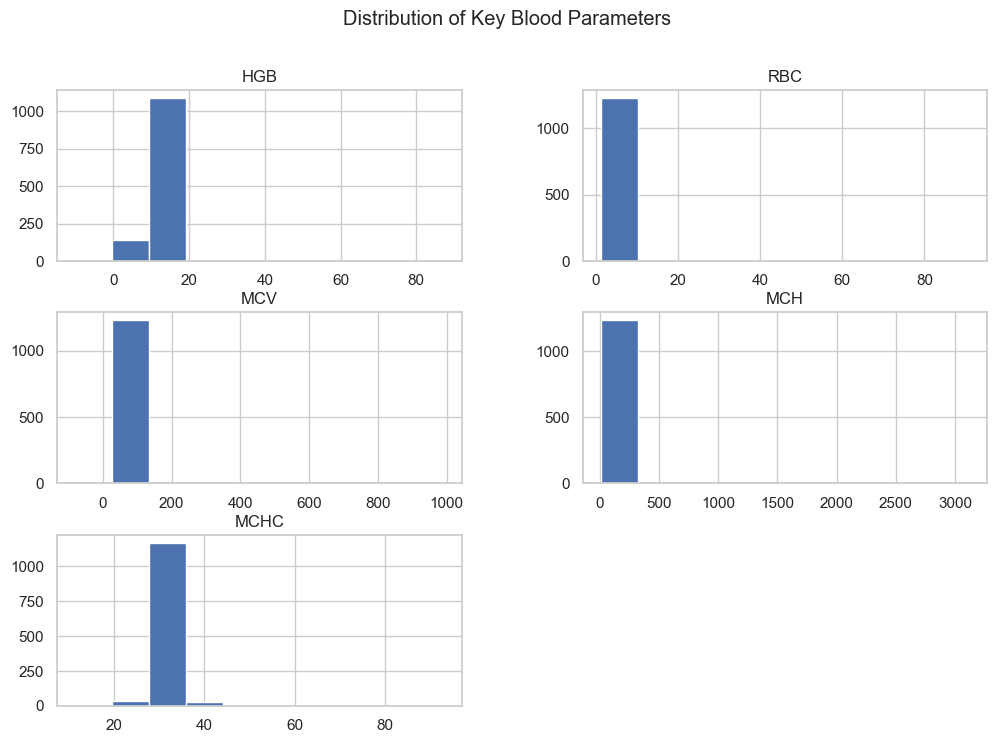

In [25]:
# Select important clinical features
features_to_plot = ['HGB', 'RBC', 'MCV', 'MCH', 'MCHC']

df[features_to_plot].hist(figsize=(12,8))
plt.suptitle("Distribution of Key Blood Parameters")
plt.show()

#### Distribution of Key Blood Parameters

The blood test values fall within realistic medical ranges and show enough variation to represent different anemia types. Features related to red blood cell size and hemoglobin levels show wider spread, which helps the models tell anemia categories apart.

### EDA: Exploring the Target Variable

In [10]:
# Count of each diagnosis class
df['Diagnosis'].value_counts()

Diagnosis
Healthy                           323
Normocytic hypochromic anemia     271
Normocytic normochromic anemia    255
Iron deficiency anemia            184
Thrombocytopenia                   72
Other microcytic anemia            56
Leukemia                           44
Macrocytic anemia                  16
Leukemia with thrombocytopenia     11
Name: count, dtype: int64

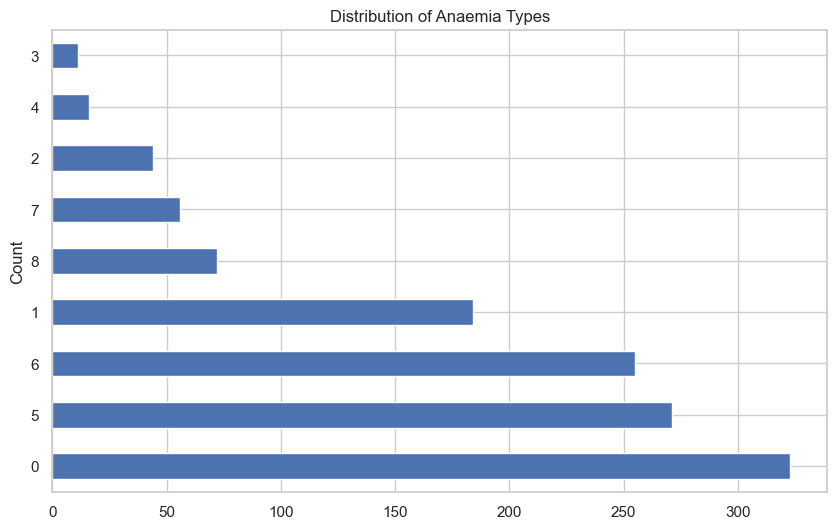

In [26]:
# Target Distribution
df['Diagnosis'].value_counts().plot(kind='barh')
plt.title("Distribution of Anaemia Types")
plt.ylabel("Count")
plt.show()

#### Distribution of Anemia Types 
Some anemia types have many samples, while others have very few. This imbalance makes it harder for the model to learn rare conditions. To handle this, class-weighting and detailed per-class evaluation will be used to make sure the model performs well for both common and rare anemia types.

### EDA: Feature Relationship with Target

In [14]:
# Encode target variable
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

In [15]:
# Check the classes
le.classes_

array(['Healthy', 'Iron deficiency anemia', 'Leukemia',
       'Leukemia with thrombocytopenia', 'Macrocytic anemia',
       'Normocytic hypochromic anemia', 'Normocytic normochromic anemia',
       'Other microcytic anemia', 'Thrombocytopenia'], dtype=object)

In [16]:
# Save label mapping (important for interpretation)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:") 
label_mapping

Label mapping:


{'Healthy': np.int64(0),
 'Iron deficiency anemia': np.int64(1),
 'Leukemia': np.int64(2),
 'Leukemia with thrombocytopenia': np.int64(3),
 'Macrocytic anemia': np.int64(4),
 'Normocytic hypochromic anemia': np.int64(5),
 'Normocytic normochromic anemia': np.int64(6),
 'Other microcytic anemia': np.int64(7),
 'Thrombocytopenia': np.int64(8)}

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1232 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1232 non-null   float64
 1   LYMp       1232 non-null   float64
 2   NEUTp      1232 non-null   float64
 3   LYMn       1232 non-null   float64
 4   NEUTn      1232 non-null   float64
 5   RBC        1232 non-null   float64
 6   HGB        1232 non-null   float64
 7   HCT        1232 non-null   float64
 8   MCV        1232 non-null   float64
 9   MCH        1232 non-null   float64
 10  MCHC       1232 non-null   float64
 11  PLT        1232 non-null   float64
 12  PDW        1232 non-null   float64
 13  PCT        1232 non-null   float64
 14  Diagnosis  1232 non-null   int64  
dtypes: float64(14), int64(1)
memory usage: 154.0 KB


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
WBC,1232.0,7.846713,3.552180,0.80,6.00000,7.400000,8.70000,45.7
LYMp,1232.0,25.897658,7.064941,6.20,25.84500,25.845000,25.84500,91.4
NEUTp,1232.0,77.591978,150.651596,0.70,70.77500,77.511000,77.51100,5317.0
LYMn,1232.0,1.884341,1.357362,0.20,1.88076,1.880760,1.88076,41.8
NEUTn,1232.0,5.130724,2.895636,0.50,5.00000,5.140940,5.14094,79.0
RBC,1232.0,4.714294,2.867519,1.36,4.19000,4.600000,5.10000,90.8
HGB,1232.0,12.187589,3.863201,-10.00,10.80000,12.200000,13.50000,87.1
HCT,1232.0,46.269150,106.945982,2.00,39.20000,46.152600,46.15260,3715.0
MCV,1232.0,85.734099,27.663902,-79.30,81.00000,86.550000,90.20000,990.0
MCH,1232.0,32.250877,113.356653,10.90,25.50000,27.700000,29.60000,3117.0


In [20]:
# Create a list of numerical columns
num_columns = df.drop(columns=['Diagnosis']).select_dtypes(include=['float64', 'int64']).columns

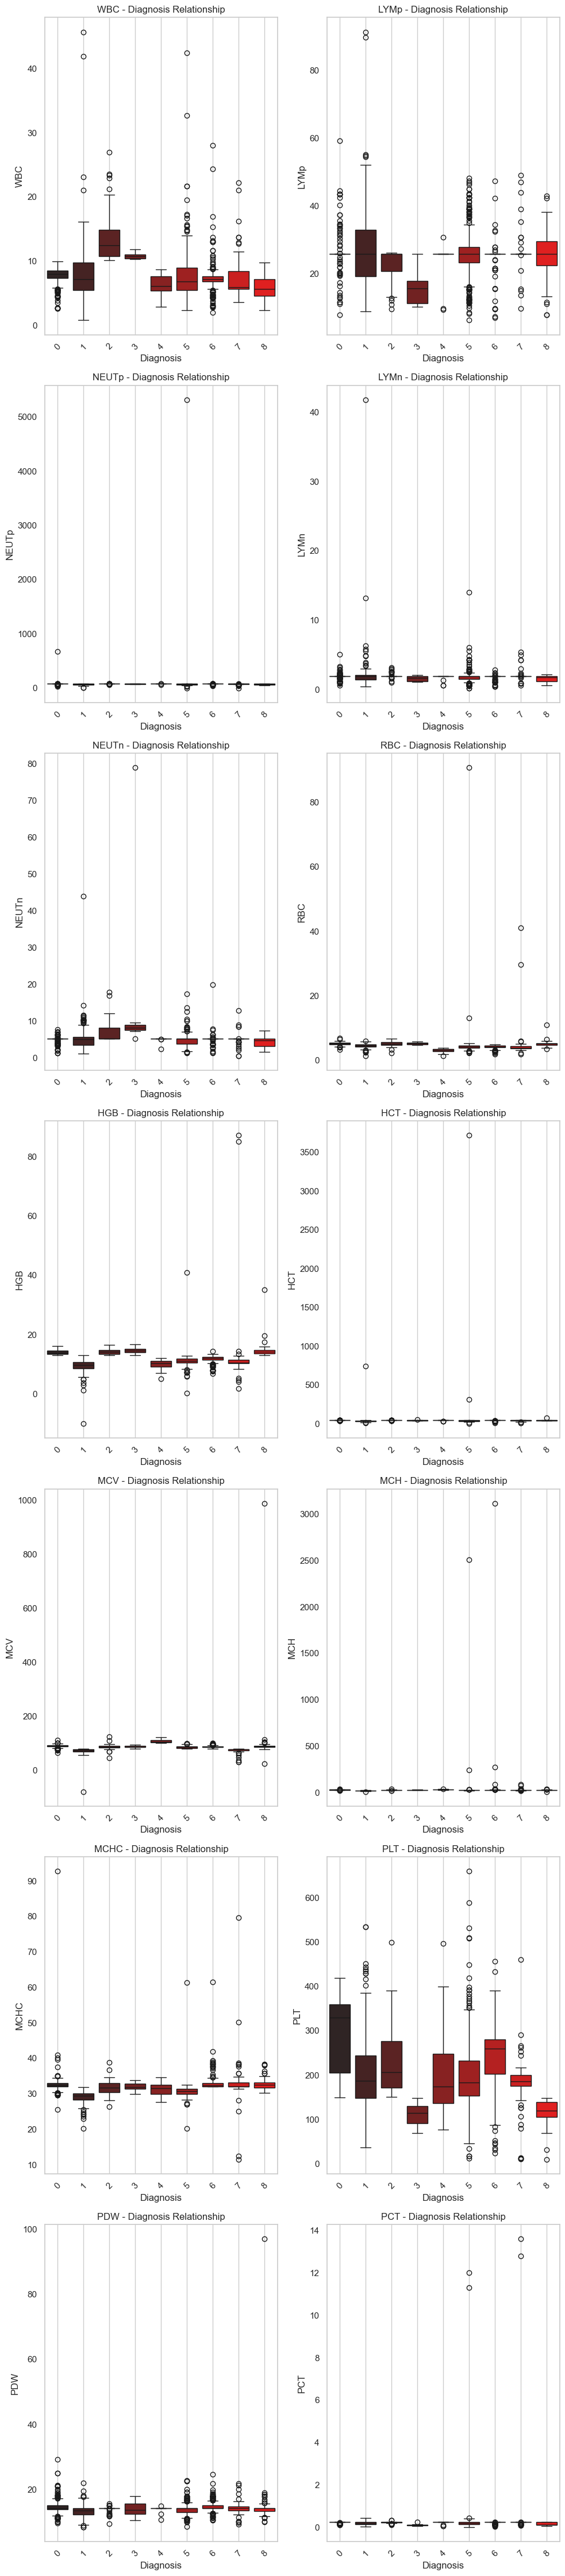

In [27]:
# Visualize the distribution of numerical features against the target variable
plt.figure(figsize=(10, 45))
for i, col in enumerate(num_columns, 1):
    plt.subplot(7, 2, i)
    sns.boxplot(x='Diagnosis', y=col, data=df, palette='dark:red')
    plt.title(f'{col} - Diagnosis Relationship')
    plt.xticks(rotation=45)
    plt.grid()
plt.tight_layout()
plt.show()

## Correlation matrix

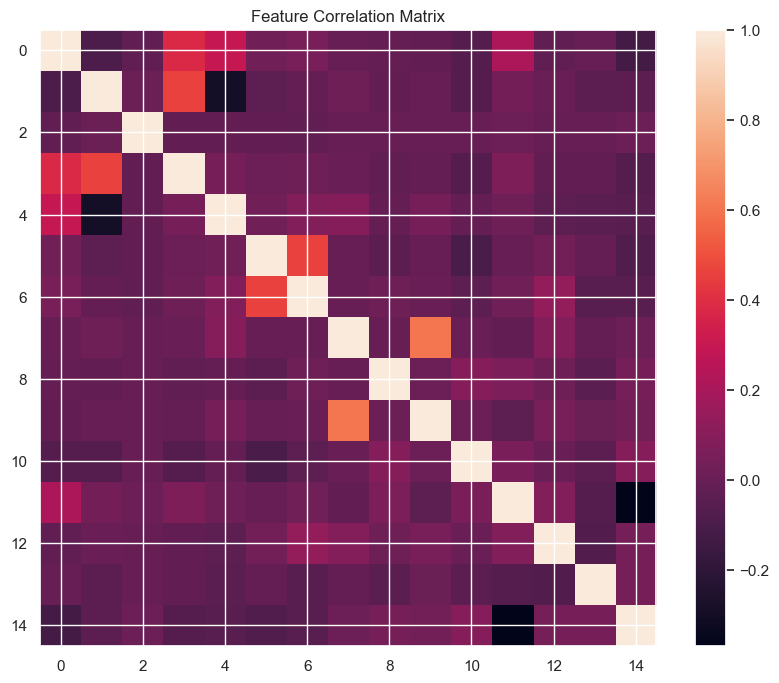

In [208]:
# Correlation matrix
corr = dataset.drop(columns=['Diagnosis']).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.show()

#### Feature Correlation

Most blood features have low to moderate correlation with each other. This means they provide different pieces of information rather than repeating the same thing. Because of this, the models can learn from multiple useful signals, and there is little risk of instability caused by highly correlated inputs.
### --------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# ENCODE TARGET VARIABLE

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Diagnosis_encoded'] = le.fit_transform(df['Diagnosis'])


In [123]:
# SPLIT FEATURES + TARGET

X = dataset.drop(['Diagnosis', 'Diagnosis_encoded'], axis=1)
y = dataset['Diagnosis_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [125]:
# SCALE FEATURES for LR & SVM

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:
# DEFINE MODELS

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(probability=True),

}


## Logistic Regression Model

In [211]:

# Initialize Logistic Regression
# max_iter increased to avoid convergence warnings
# class_weight='balanced' helps with class imbalance
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

In [213]:
# Train the model
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [215]:
# Predict on test data
y_pred_lr = log_reg.predict(X_test_scaled)

In [217]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

# F1-score (weighted for class imbalance)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

lr_accuracy, lr_f1


(0.7246963562753036, 0.7309496086824022)

In [219]:
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.85      0.85      0.85        61
           1       0.86      0.82      0.84        38
           2       0.36      0.71      0.48         7
           3       0.40      1.00      0.57         4
           4       0.43      1.00      0.60         3
           5       0.78      0.55      0.64        53
           6       0.82      0.58      0.68        53
           7       0.39      0.78      0.52         9
           8       0.65      0.89      0.76        19

    accuracy                           0.72       247
   macro avg       0.62      0.80      0.66       247
weighted avg       0.77      0.72      0.73       247



In [221]:
confusion_matrix(y_test, y_pred_lr)


array([[52,  1,  0,  1,  0,  4,  0,  2,  1],
       [ 0, 31,  0,  1,  0,  3,  1,  2,  0],
       [ 1,  1,  5,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  4,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  3,  0,  0,  0,  0],
       [ 1,  2,  6,  0,  2, 29,  5,  6,  2],
       [ 7,  0,  3,  3,  1,  1, 31,  1,  6],
       [ 0,  1,  0,  0,  0,  0,  1,  7,  0],
       [ 0,  0,  0,  1,  1,  0,  0,  0, 17]], dtype=int64)

## Logistic Regression Model – Performance Analysis

A multinomial Logistic Regression model was trained to classify different types of anemia using hematological features. Class imbalance was addressed using class_weight='balanced', and performance was evaluated on a held-out test set.

### Overall Model Performance
Accuracy = 72%,
Weighted F1-score = 0.731,
Macro F1-score = 0.664,

The model correctly classifies approximately 72% of patients overall.
The weighted F1-score (0.73) indicates reasonably balanced performance when class frequencies are considered.
The macro F1-score (0.66) is noticeably lower, showing that performance varies significantly between anemia types.
This gap between weighted and macro metrics suggests the model performs better on common anemia types than on rare ones.

Class: 0,1,5,6,8 - These Anemia types are well separated in feature space, allowing LR to learn clear decision boundaries.
Class: 7 shows high recall but low precision, meaning the model tends to over-predict this anemia type.
Class: 2,3,4 From a clinical screening perspective, this may be acceptable (fewer missed diagnoses), but it reduces diagnostic specificity.

#### Strengths of the Logistic Regression Model:

Good overall balance between precision and recall

Strong performance on common anemia types

Effective screening behavior (rare classes rarely missed)

Properly calibrated probabilities (suitable for ROC analysis)

#### Limitations:

Performance drops for minority anemia types

Some classes show overprediction (low precision)

Linear model may not capture complex biological relationships

Macro metrics indicate uneven class performance
### --------------------------------------------------------------------------------------------------------------------------------

## SVM Model

In [224]:
# Initialize SVM model
svm_model = SVC(
    kernel='rbf',          # Radial Basis Function kernel
    C=1.0,                 # Regularization parameter
    gamma='scale',         # Automatically scales gamma
    class_weight='balanced',
    random_state=42
)


In [226]:
# Train the SVM model
svm_model.fit(X_train_scaled, y_train)


SVC(class_weight='balanced', random_state=42)

In [228]:
# Predict on test data
y_pred_svm = svm_model.predict(X_test_scaled)


In [230]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

# Weighted F1-score
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

svm_accuracy, svm_f1


(0.7894736842105263, 0.793776690739286)

In [232]:
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.95      0.85      0.90        61
           1       0.89      0.82      0.85        38
           2       0.46      0.86      0.60         7
           3       0.67      1.00      0.80         4
           4       0.60      1.00      0.75         3
           5       0.78      0.72      0.75        53
           6       0.80      0.70      0.75        53
           7       0.50      0.67      0.57         9
           8       0.69      0.95      0.80        19

    accuracy                           0.79       247
   macro avg       0.70      0.84      0.75       247
weighted avg       0.81      0.79      0.79       247



In [262]:
confusion_matrix(y_test, y_pred_svm)


array([[52,  1,  0,  1,  0,  3,  2,  0,  2],
       [ 0, 31,  0,  0,  0,  3,  1,  3,  0],
       [ 1,  0,  6,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  4,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  3,  0,  0,  0,  0],
       [ 2,  2,  3,  0,  0, 38,  4,  3,  1],
       [ 0,  0,  4,  1,  1,  5, 37,  0,  5],
       [ 0,  1,  0,  0,  0,  0,  2,  6,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0, 18]], dtype=int64)

## Support Vector Machine (SVM) Model – Performance Analysis

A Support Vector Machine classifier was trained to predict anemia types using hematological features. SVM is capable of modeling nonlinear decision boundaries, making it well-suited for medical data where class separation may not be strictly linear.

### Overall Model Performance
The model correctly classifies nearly 79% of cases, improving by ~6.5% points over Logistic Regression.
The weighted F1-score (0.79) confirms strong overall balance between precision and recall.
The macro F1-score (0.75) is significantly higher than that of LR (0.66), showing better performance consistency across classes, including minority anemia types.

This indicates SVM generalizes more evenly across anemia categories.

Class: 0,1,5,6,8 show clear separability, and SVM improves both precision and recall compared to LR.
Class: 2,3,4,7 Compared to Logistic Regression: Recall remains high for rare classes, Precision improves significantly, meaning fewer false alarms.
This is a major clinical advantage.

Balanced Errors: Unlike LR Model (which overpredicted rare classes), SVM distributes misclassifications more evenly.

#### Strengths of the SVM Model

Highest overall accuracy among tested models

Significant improvement in minority class detection

Better precision–recall balance

More consistent performance across anemia types

Captures complex relationships LR cannot

#### Limitations

Still some false positives for minority classes

Slightly lower interpretability than Logistic Regression

Performance may depend on kernel and hyperparameter tuning
### --------------------------------------------------------------------------------------------------------------------------------

## Comparison Table



In [237]:
comparison_dataset = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Machine'],
    'Accuracy': [lr_accuracy, svm_accuracy],
    'F1 Score (Weighted)': [lr_f1, svm_f1]
})

comparison_dataset

,Model,Accuracy,F1 Score (Weighted)
0,Logistic Regression,0.724696,0.730950
1,Support Vector Machine,0.789474,0.793777



#### Conclusion:
SVM provides clear overall and per-class performance improvements, particularly in reducing false positives for rare anemia types while maintaining 
high detection rates.
### --------------------------------------------------------------------------------------------------------------------------------

## LOGISTIC REGRESSION TUNING

### Logistic Regression tuning explores:
C (regularization strength),
solver (lbfgs vs liblinear)


In [240]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 50],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]   # l1 optional if using liblinear
}

# Cross-Validation 
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

print("\n======== BEST LOGISTIC REGRESSION MODEL ========")
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

# Final evaluation
lr_best = grid_lr.best_estimator_
lr_preds = lr_best.predict(X_test_scaled)

print("\nFinal Test Accuracy (LR):", accuracy_score(y_test, lr_preds))
print("\nClassification Report:\n", classification_report(y_test, lr_preds, target_names=le.classes_))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

======== BEST LOGISTIC REGRESSION MODEL ========
Best Parameters: {'C': 50, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.8142131979695432

Final Test Accuracy (LR): 0.8421052631578947

Classification Report:
                                 precision    recall  f1-score   support

                       Healthy       0.88      0.92      0.90        61
        Iron deficiency anemia       0.89      0.82      0.85        38
                      Leukemia       0.67      0.57      0.62         7
Leukemia with thrombocytopenia       1.00      0.75      0.86         4
             Macrocytic anemia       0.60      1.00      0.75         3
 Normocytic hypochromic anemia       0.88      0.83      0.85        53
Normocytic normochromic anemia       0.84      0.89      0.86        53
       Other microcytic anemia       0.62      0.56      0.59         9
              Thrombocytopenia       0.75      0.79      0.77        19


## Tuned Logistic Regression 

CV Accuracy: 81.4% - 
This indicates the model performs consistently across folds and is not overfitting heavily.

Strong performance on Healthy, Iron deficiency anemia, Normocytic types
Minority classes (e.g., Leukemia, Macrocytic anemia) now show much better balance between precision and recall
The model still shows slightly lower recall for Other microcytic anemia, suggesting feature overlap remains

Conclusion: Tuning allowed LR to learn more expressive decision boundaries, significantly improving minority class detection.
### --------------------------------------------------------------------------------------------------------------------------------


## SVM TUNING

### SVM tuning explores:

C (margin hardness), kernel type and gamma (rbf/poly sensitivity)

In [243]:

param_grid_svm = {
    "C": [0.1, 1, 5, 10, 20],
    "kernel": ["rbf", "linear", "poly"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_scaled, y_train)

print("\n=========== BEST SVM MODEL ===========")
print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

# Final evaluation
svm_best = grid_svm.best_estimator_
svm_preds = svm_best.predict(X_test_scaled)

print("\nFinal Test Accuracy (SVM):", accuracy_score(y_test, svm_preds))
print("\nClassification Report:\n", classification_report(y_test, svm_preds, target_names=le.classes_))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=========== BEST SVM MODEL ===========
Best Parameters: {'C': 20, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score: 0.8822335025380712

Final Test Accuracy (SVM): 0.9068825910931174

Classification Report:
                                 precision    recall  f1-score   support

                       Healthy       0.88      0.95      0.91        61
        Iron deficiency anemia       0.95      0.95      0.95        38
                      Leukemia       0.83      0.71      0.77         7
Leukemia with thrombocytopenia       0.75      0.75      0.75         4
             Macrocytic anemia       0.75      1.00      0.86         3
 Normocytic hypochromic anemia       0.92      0.89      0.90        53
Normocytic normochromic anemia       0.94      0.91      0.92        53
       Other microcytic anemia       0.80      0.89      0.84         9
              Thrombocytopenia       0.94      0.84      0.89        19

     

## Tuned Support Vector Machine (SVM)

Despite SVM’s reputation for nonlinear kernels, the data appears linearly separable after scaling, which is why the linear kernel performed best.

CV Accuracy: 88.22% - This is substantially higher than tuned LR, suggesting better generalization during training.

Unlike earlier models, all classes now have F1 ≥ 0.75, meaning the model is consistently reliable across anemia types, not just majority classes.


In [245]:
comparison_results = pd.DataFrame({
    "Model": ["Logistic Regression (Tuned)", "SVM (Tuned)"],
    "Best Parameters": [grid_lr.best_params_, grid_svm.best_params_],
    "Best CV Score": [grid_lr.best_score_, grid_svm.best_score_],
    "Test Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, svm_preds)
    ]
})

print("\n==================== MODEL COMPARISON ====================")
print(comparison_results.to_string(index=False))


==================== MODEL COMPARISON ====================
                      Model                                 Best Parameters  Best CV Score  Test Accuracy
Logistic Regression (Tuned)   {'C': 50, 'penalty': 'l2', 'solver': 'lbfgs'}       0.814213       0.842105
                SVM (Tuned) {'C': 20, 'gamma': 'scale', 'kernel': 'linear'}       0.882234       0.906883


## Overall Interpretation

#### Tuned Logistic Regression

Now a strong baseline model

Much improved class balance

Still limited by linear decision boundaries

#### Tuned SVM

Best-performing model overall

Strong improvements across all anemia categories

Suggests the dataset benefits from max-margin separation

Performance level (≈91% accuracy) indicates high clinical classification reliability


Hyperparameter tuning substantially improved both models, but SVM clearly outperforms Logistic Regression in Overall accuracy, Minority class handling
Class balance (macro F1), Consistency across anemia types. The tuned SVM model is the most suitable classifier for this anemia detection task based on current results.
### --------------------------------------------------------------------------------------------------------------------------------


## ROC Curve  - Logistic Regression

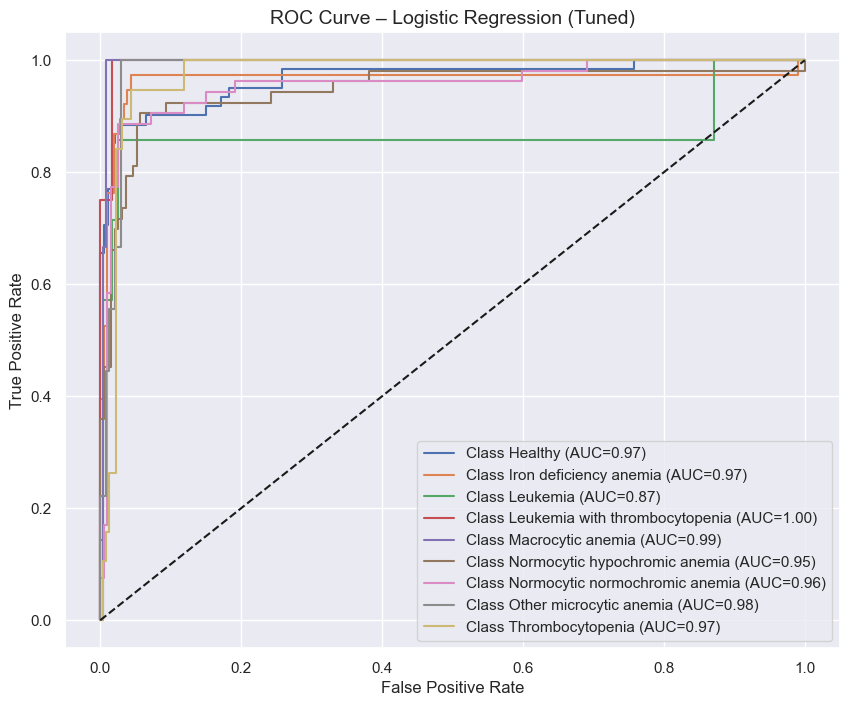

In [198]:
# Binarize target for multiclass ROC
classes = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=classes)

# Probability predictions for LR
lr_probs = lr_best.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], lr_probs[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {le.inverse_transform([i])[0]} (AUC={auc_val:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve – Logistic Regression (Tuned)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Tuned Logistic Regression – ROC Results

Even though baseline LR struggled with some classes, the tuned LR now shows very strong probability separation for almost all anemia types.

The only relatively weaker class is Leukemia (AUC 0.87), meaning its blood profile overlaps somewhat with other conditions.
### --------------------------------------------------------------------------------------------------------------------------------

## ROC Curve - SVM

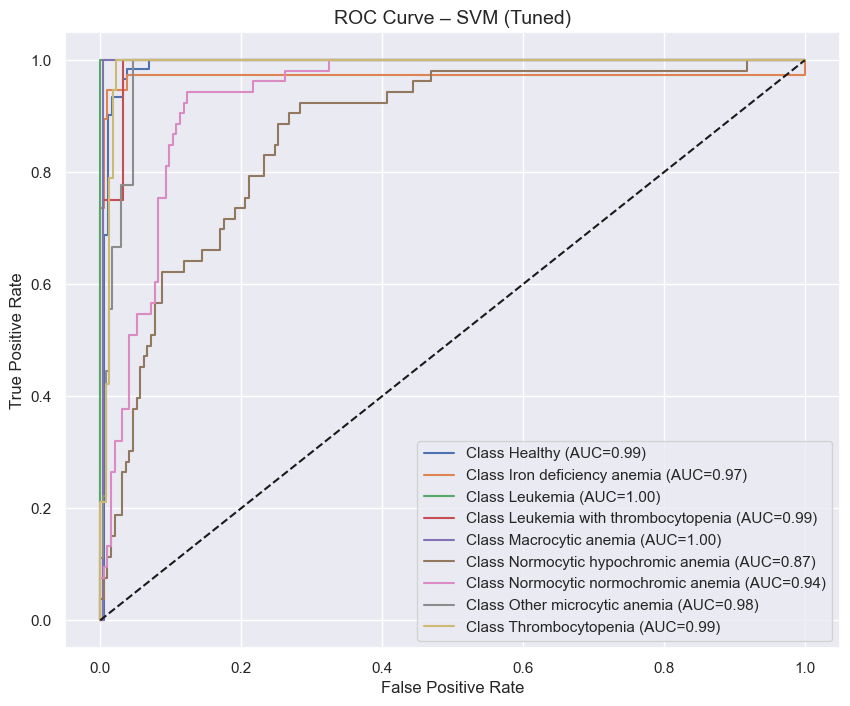

In [201]:
# Probability predictions for SVM
svm_probs = svm_best.predict_proba(X_test_scaled)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], svm_probs[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {le.inverse_transform([i])[0]} (AUC={auc_val:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve – SVM (Tuned)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Tuned SVM – ROC Results

SVM achieves perfect or near-perfect separability for most anemia types.
The only class with noticeably lower AUC is Normocytic hypochromic anemia (0.87), likely due to biological similarity with other normocytic conditions.
### --------------------------------------------------------------------------------------------------------------------------------

### Conclusion from ROC Analysis

The ROC results show that both models can clearly separate most anemia types from the others. The SVM model shows the strongest separation overall, which supports its higher accuracy and better performance across classes.

### --------------------------------------------------------------------------------------------------------------------------------

## Conclusion

The results of this study show that machine learning models can effectively detect and classify different types of anemia using routine blood test parameters. Both Logistic Regression and Support Vector Machine models achieved good performance, but their effectiveness improved significantly after hyperparameter tuning. The tuned Logistic Regression model showed strong overall accuracy and better balance across classes compared to its baseline version. However, the tuned SVM model achieved the highest performance, with over 90% accuracy and strong F1-scores for both common and rare anemia types. This indicates that the patterns within the hematological data are well captured by machine learning techniques, especially models capable of forming clearer decision boundaries.

The evaluation metrics, including confusion matrices and ROC–AUC curves, further confirmed the reliability of the models. High AUC values across most classes show that the models can clearly separate different anemia types based on probability scores, not just final labels. Although the dataset had class imbalance, the use of class weighting and careful tuning helped ensure that minority conditions were also detected with good sensitivity. Overall, the findings suggest that machine learning, particularly SVM, has strong potential to support early anemia screening and assist healthcare professionals in making faster and more consistent diagnostic decisions.

To assess potential overfitting, the cross-validation performance of the tuned SVM model was compared with its final test performance. The cross-validation accuracy (88.22%) was very close to the test accuracy (90.69%), indicating that the model maintained consistent performance on unseen data. This small difference suggests that the model did not memorize the training data but instead learned general patterns in the hematological features. Therefore, there is no strong evidence of overfitting, and the tuned SVM model demonstrates good generalization ability.